In [30]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')
%matplotlib inline 


In [31]:
import sqlite3

# connect to database
conn = sqlite3.connect("../Data/diabetes_project.db")

In [32]:
data=pd.read_sql("Select * FROM transformed_data",conn)

In [33]:
data.columns=data.columns.str.strip()

In [34]:
data.columns

Index(['AGE', 'GENDER', 'SUBJECT TYPE', 'HBA1C', 'PP2 [<140 mg/dl]',
       'FBS [74-110 mg/dl]', 'BMI', 'WAIST TO HIP RATIO', 'TOBACCO',
       'PHYSICAL ACTIVITY', 'ALCOHOL', 'SERUM TRIGLYCERIDE [<150 mg/dl]',
       'HDL CHOLESTEROL[200 mg/dl]', 'CHOL/HDL', 'LDL/HDL'],
      dtype='object')

In [35]:
data.head(10)

,AGE,GENDER,SUBJECT TYPE,HBA1C,PP2 [<140 mg/dl],FBS [74-110 mg/dl],BMI,WAIST TO HIP RATIO,TOBACCO,PHYSICAL ACTIVITY,ALCOHOL,SERUM TRIGLYCERIDE [<150 mg/dl],HDL CHOLESTEROL[200 mg/dl],CHOL/HDL,LDL/HDL
0,70,0,0,5.5,120,100,23.828652,0.944444,3,0,1,144,69,2.83,1.41
1,60,1,0,5.6,132,102,25.873479,0.942857,0,1,0,146,94,1.66,0.35
2,60,1,0,5.0,131,101,26.529879,0.945946,0,1,0,144,69,2.83,1.41
3,43,0,0,5.5,117,111,25.037704,0.945946,0,0,1,146,94,1.66,0.35
4,65,1,0,5.7,111,120,29.018860,0.944444,0,1,0,165,64,1.97,0.45
5,75,1,0,5.3,125,105,23.949540,0.942857,1,1,0,81,51,2.86,1.55
6,57,0,0,6.1,141,95,24.654615,0.945946,2,0,1,144,71,2.49,1.08
7,70,0,0,5.5,120,89,24.408675,0.944444,2,0,1,97,66,2.05,0.76
8,48,1,0,5.6,132,108,23.031853,0.944444,0,1,0,202,49,4.06,2.24
9,29,1,0,5.0,131,114,22.855612,0.942857,0,1,0,217,74,2.80,1.22


In [36]:
data.shape

(1312, 15)

In [37]:
data.isnull().sum()

AGE                                0
GENDER                             0
SUBJECT TYPE                       0
HBA1C                              0
PP2 [<140 mg/dl]                   0
FBS [74-110 mg/dl]                 0
BMI                                0
WAIST TO HIP RATIO                 0
TOBACCO                            0
PHYSICAL ACTIVITY                  0
ALCOHOL                            0
SERUM TRIGLYCERIDE [<150 mg/dl]    0
HDL CHOLESTEROL[200 mg/dl]         0
CHOL/HDL                           0
LDL/HDL                            0
dtype: int64

In [38]:
data['SUBJECT TYPE'].value_counts()

SUBJECT TYPE
1    683
0    629
Name: count, dtype: int64

In [39]:
X=data.drop('SUBJECT TYPE',axis=1)
Y= data['SUBJECT TYPE']

In [40]:
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.30,random_state=42,stratify=Y)

In [41]:
skf=StratifiedKFold(n_splits=10,random_state=42,shuffle=True)

In [42]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((918, 14), (394, 14), (918,), (394,))

In [43]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,roc_auc_score,f1_score,roc_curve)

In [45]:
import psutil
print(psutil.virtual_memory())

svmem(total=8210415616, available=1053290496, percent=87.2, used=7157125120, free=1053290496)


In [46]:
params={
    'LogisticRegression' : {
        'model' : LogisticRegression(max_iter=2000),
        'param':  {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        },
        'scaled': True
    },
    'RandomForestClassifier':{
        'model': RandomForestClassifier(random_state=42),
         "param": {
            "n_estimators": [100, 300],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        },
        'scaled': False
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "param": {
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5, 10]
        },
        'scaled': False
    },

    "SVC": {
        "model": SVC(probability=True),
        "param": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "linear"],
            "gamma": ["scale", "auto"]
        },
        'scaled': True
    },
    'Adaboost':{
        'model': AdaBoostClassifier(random_state=42),
        'param': {
            'n_estimators':[50,75,100,200],
            'learning_rate': [0.01,0.1,0.7,1]
        },
        'scaled': False
    }
    }
    

In [ ]:
best_models={}
results=[]
for name,config in params.items():

    grid=GridSearchCV(
        config['model'],
        config['param'],
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    if config['scaled']:
        grid.fit(X_train_scaled,Y_train)
    else:
        grid.fit(X_train,Y_train)
    best_model=grid.best_estimator_
    best_models[name]=best_model
    # Evaluation
    if config['scaled']:
        Y_pred= best_model.predict(X_test_scaled)
        Y_pred_Prob=best_model.predict_proba(X_test_scaled)[:,1]
    else:
       Y_pred= best_model.predict(X_test)
       Y_pred_Prob=best_model.predict_proba(X_test)[:,1]
    
    results.append({
        'Model':name,
        'CV AUC(mean)': grid.best_score_,
        'Accuracy': round(accuracy_score(Y_test,Y_pred),2),
        'Precision':round(precision_score(Y_test,Y_pred),2),
        'recall': round(recall_score(Y_test,Y_pred),2),
        'F1_Score': round(f1_score(Y_test,Y_pred),2),
        'AUC SCORE':round(roc_auc_score(Y_test,Y_pred_Prob),2)
    })



In [ ]:
nb_model=GaussianNB()
nb_model.fit(X_train_scaled,Y_train)

Y_pred=nb_model.predict(X_test_scaled)
Y_pred_Prob=nb_model.predict_proba(X_test_scaled)[:,1]

results.append({
        'Model':'Naive Bayes',
        'CV AUC(mean)': np.nan,
        'Accuracy': round(accuracy_score(Y_test,Y_pred),2),
        'Precision':round(precision_score(Y_test,Y_pred),2),
        'recall': round(recall_score(Y_test,Y_pred),2),
        'F1_Score': round(f1_score(Y_test,Y_pred),2),
        'AUC SCORE':round(roc_auc_score(Y_test,Y_pred_Prob),2)
    })
best_models["Naive Bayes"] = nb_model

: 

: 

In [ ]:
Results_Data=pd.DataFrame(results).sort_values(by='AUC SCORE',ascending=False)

: 

: 

In [ ]:
Results_Data

,Model,CV AUC(mean),Accuracy,Precision,recall,F1_Score,AUC SCORE
1,RandomForestClassifier,0.978772,0.90,0.95,0.86,0.90,0.96
4,Adaboost,0.962459,0.90,0.95,0.85,0.90,0.96
3,SVC,0.935315,0.86,0.90,0.82,0.86,0.93
2,Decision Tree,0.937256,0.87,0.96,0.78,0.86,0.92
0,LogisticRegression,0.912393,0.82,0.85,0.79,0.82,0.89
5,Naive Bayes,NaN,0.82,0.89,0.75,0.81,0.89


: 

: 

In [ ]:
Results_Data.to_excel('new_Results_ordered.xlsx',index=False)

: 

: 

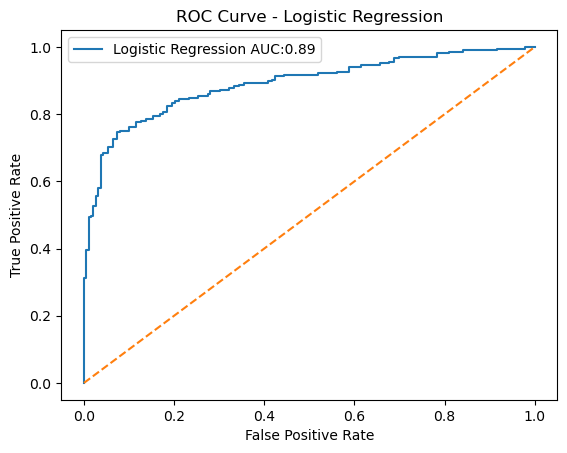

: 

: 

In [ ]:
log_model=best_models['LogisticRegression']
Y_pred_logprob=log_model.predict_proba(X_test_scaled)[:,1]

fpr,tpr,_=roc_curve(Y_test,Y_pred_logprob)
AUC=round(roc_auc_score(Y_test,Y_pred_logprob),3)

plt.Figure()
plt.plot(fpr,tpr,label= f'Logistic Regression AUC:{AUC}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("roc_logistic.png", dpi=300, bbox_inches='tight')
plt.show()


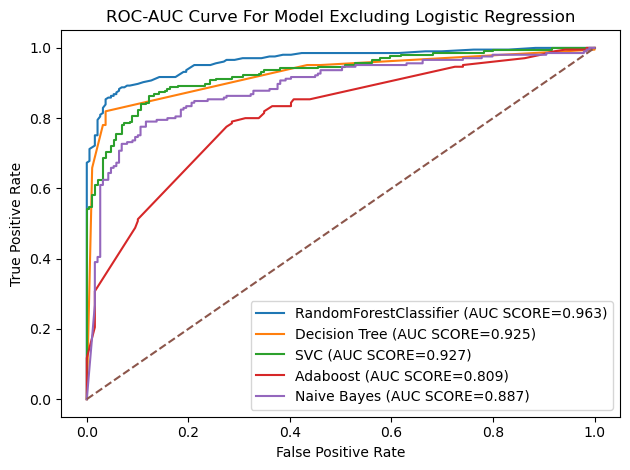

: 

: 

In [ ]:
plt.Figure(figsize=(15,15))
for name,model in best_models.items():
    if name =='LogisticRegression':
        continue
    if name in ['RandomForestClassifier','Decision Tree']:
        Y_prob_curve = model.predict_proba(X_test)[:,1]
    else:
        Y_prob_curve = model.predict_proba(X_test_scaled)[:,1]
    fpr,tpr,_=roc_curve(Y_test,Y_prob_curve)
    AUC_score=roc_auc_score(Y_test,Y_prob_curve)
    plt.plot(fpr,tpr,label=f"{name} (AUC SCORE={AUC_score:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve For Model Excluding Logistic Regression")
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.savefig('Roc-auc-combined.png',dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
importance_df=pd.DataFrame(index=X.columns)
importance_df["RandomForestClassifier"] = best_models["RandomForestClassifier"].feature_importances_

importance_df = importance_df.sort_values(
    by="RandomForestClassifier", ascending=False
)

importance_df.head(15)

,RandomForestClassifier
FBS [74-110 mg/dl],0.176532
PP2 [<140 mg/dl],0.171766
ALCOHOL,0.113947
HBA1C,0.093689
PHYSICAL ACTIVITY,0.079428
SERUM TRIGLYCERIDE [<150 mg/dl],0.069432
CHOL/HDL,0.061096
LDL/HDL,0.058671
BMI,0.043912
HDL CHOLESTEROL[200 mg/dl],0.040756


: 

: 

<Figure size 600x500 with 0 Axes>

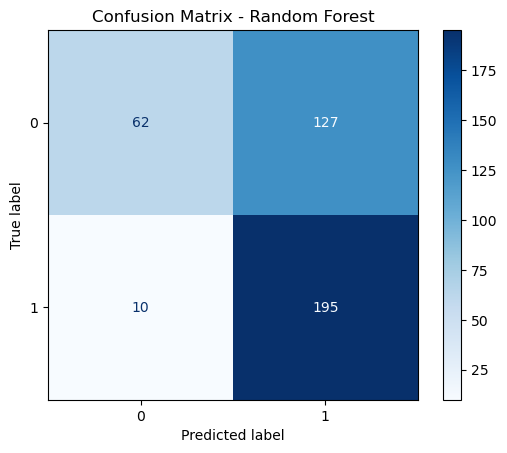

: 

: 

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
rf_model = best_models["RandomForestClassifier"]
y_pred_rf = rf_model.predict(X_test_scaled)

# Compute confusion matrix
cm_rf = confusion_matrix(Y_test, y_pred_rf)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.grid(False)
plt.savefig('confusion_matrix.png',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
cm_rf = confusion_matrix(Y_test, y_pred_rf)

: 

: 

In [ ]:
print(cm_rf)

[[ 62 127]
 [ 10 195]]


: 

: 

In [ ]:
import joblib

joblib.dump(rf_model, "../Models/random_forest_model.pkl")

['../Models/random_forest_model.pkl']

: 

: 

: 

: 

: 

: 